<a href="https://colab.research.google.com/github/atharvsalokhe30/GenAI_Project_Practice-/blob/main/VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys, os, time, math, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from IPython.display import display, Image as IPImage

In [ ]:
print("Python     :", sys.version.split()[0])
print("Tensorflow :", tf.__version__)
print("Keras      :", keras.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU        :", [g.name for g in gpus] if gpus else "None  (CPU only - still works, just slower)")

Python     : 3.13.15
Tensorflow : 2.20.0
Keras      : 3.13.2
GPU        : None  (CPU only - still works, just slower)


In [ ]:
np.random.seed(42)
tf.random.set_seed(42)


In [ ]:
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"]  = False
plt.rcParams["font.size"]  = 9
plt.rcParams["figure.facecolor"]  = "white"
print("\nSetup complete.")


Setup complete.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions

t0= time.time()
vgg_full = VGG16(weights="imagenet", include_top=True)
print(f"weights loaded in {time.time()-t0:.1f} s (~528 MB the first time)\n")

vgg_full.summary()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step
weights loaded in 37.0 s (~528 MB the first time)



Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def out_shape(layer):
  try:    return tuple(layer.output.shape)
  except: return tuple(layer.output_shape)
rows = []
for i, l in enumerate(vgg_full.layers):
  rows.append(dict(idx=i,
                   name=l.name,
                   type=l.__class__.__name__,
                   output_shape=str(out_shape(l)),
                   params=l.count_params()))
  layer_df = pd.DataFrame(rows)
  layer_df["params_%"] = (100 * layer_df["params"] / layer_df["params"].sum()).round(2)

  display(layer_df)
  print("TOTAL parameters :", f"{vgg_full.count_params():,}")
  print("conv base params :", f"{sum(l.count_params() for l in vgg_full.layers[:19]):,}")
  print("FC head params   :", f"{sum(l.count_params() for l in vgg_full.layers[19:]):,}")

,idx,name,type,output_shape,params,params_%
0,0,input_layer,InputLayer,"(None, 224, 224, 3)",0,NaN


TOTAL parameters : 138,357,544
conv base params : 14,714,688
FC head params   : 123,642,856


,idx,name,type,output_shape,params,params_%
0,0,input_layer,InputLayer,"(None, 224, 224, 3)",0,0.0
1,1,block1_conv1,Conv2D,"(None, 224, 224, 64)",1792,100.0


TOTAL parameters : 138,357,544
conv base params : 14,714,688
FC head params   : 123,642,856


,idx,name,type,output_shape,params,params_%
0,0,input_layer,InputLayer,"(None, 224, 224, 3)",0,0.00
1,1,block1_conv1,Conv2D,"(None, 224, 224, 64)",1792,4.63
2,2,block1_conv2,Conv2D,"(None, 224, 224, 64)",36928,95.37


...

TOTAL parameters : 138,357,544
conv base params : 14,714,688
FC head params   : 123,642,856


,idx,name,type,output_shape,params,params_%
0,0,input_layer,InputLayer,"(None, 224, 224, 3)",0,0.00
1,1,block1_conv1,Conv2D,"(None, 224, 224, 64)",1792,0.00
2,2,block1_conv2,Conv2D,"(None, 224, 224, 64)",36928,0.03
3,3,block1_pool,MaxPooling2D,"(None, 112, 112, 64)",0,0.00
4,4,block2_conv1,Conv2D,"(None, 112, 112, 128)",73856,0.06
5,5,block2_conv2,Conv2D,"(None, 112, 112, 128)",147584,0.11
6,6,block2_pool,MaxPooling2D,"(None, 56, 56, 128)",0,0.00
7,7,block3_conv1,Conv2D,"(None, 56, 56, 256)",295168,0.22
8,8,block3_conv2,Conv2D,"(None, 56, 56, 256)",590080,0.44
9,9,block3_conv3,Conv2D,"(None, 56, 56, 256)",590080,0.44


TOTAL parameters : 138,357,544
conv base params : 14,714,688
FC head params   : 123,642,856


,idx,name,type,output_shape,params,params_%
0,0,input_layer,InputLayer,"(None, 224, 224, 3)",0,0.00
1,1,block1_conv1,Conv2D,"(None, 224, 224, 64)",1792,0.00
2,2,block1_conv2,Conv2D,"(None, 224, 224, 64)",36928,0.03
3,3,block1_pool,MaxPooling2D,"(None, 112, 112, 64)",0,0.00
4,4,block2_conv1,Conv2D,"(None, 112, 112, 128)",73856,0.05
5,5,block2_conv2,Conv2D,"(None, 112, 112, 128)",147584,0.11
6,6,block2_pool,MaxPooling2D,"(None, 56, 56, 128)",0,0.00
7,7,block3_conv1,Conv2D,"(None, 56, 56, 256)",295168,0.21
8,8,block3_conv2,Conv2D,"(None, 56, 56, 256)",590080,0.43
9,9,block3_conv3,Conv2D,"(None, 56, 56, 256)",590080,0.43


TOTAL parameters : 138,357,544
conv base params : 14,714,688
FC head params   : 123,642,856


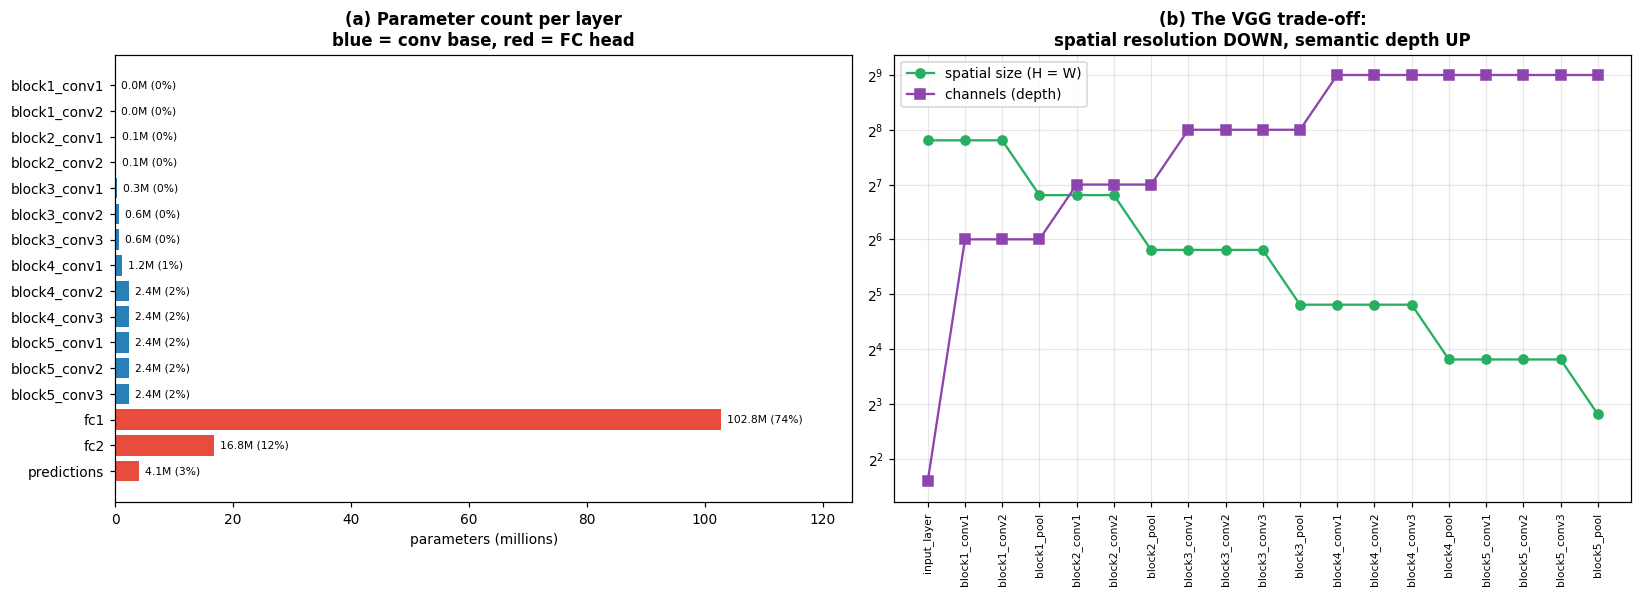

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15, 5.5))

pdf = layer_df[layer_df["params"] > 0]
cols = ["#e74c3c" if n.startswith("fc") or n == "predictions" else "#2980b9" for n in pdf["name"]]
ax[0].barh(pdf["name"], pdf["params"] / 1e6, color=cols)
ax[0].invert_yaxis()
ax[0].set_xlabel("parameters (millions)")
ax[0].set_title("(a) Parameter count per layer\nblue = conv base, red = FC head", fontweight="bold")
for y, (v, p) in enumerate(zip(pdf["params"] / 1e6, pdf["params_%"])):
    ax[0].text(v + 1, y, f"{v:.1f}M ({p:.0f}%)", va="center", fontsize=7)
ax[0].set_xlim(0, 125)

conv = [(l.name, out_shape(l)) for l in vgg_full.layers if len(out_shape(l)) == 4]
names   = [c[0] for c in conv]
spatial = [c[1][1] for c in conv]
chans   = [c[1][3] for c in conv]
xx = np.arange(len(names))
ax[1].plot(xx, spatial, "o-", color="#27ae60", label="spatial size (H = W)")
ax[1].plot(xx, chans,   "s-", color="#8e44ad", label="channels (depth)")
ax[1].set_yscale("log", base=2)
ax[1].set_xticks(xx); ax[1].set_xticklabels(names, rotation=90, fontsize=7)
ax[1].legend(); ax[1].grid(alpha=.3)
ax[1].set_title("(b) The VGG trade-off:\nspatial resolution DOWN, semantic depth UP", fontweight="bold")
plt.tight_layout(); plt.show()

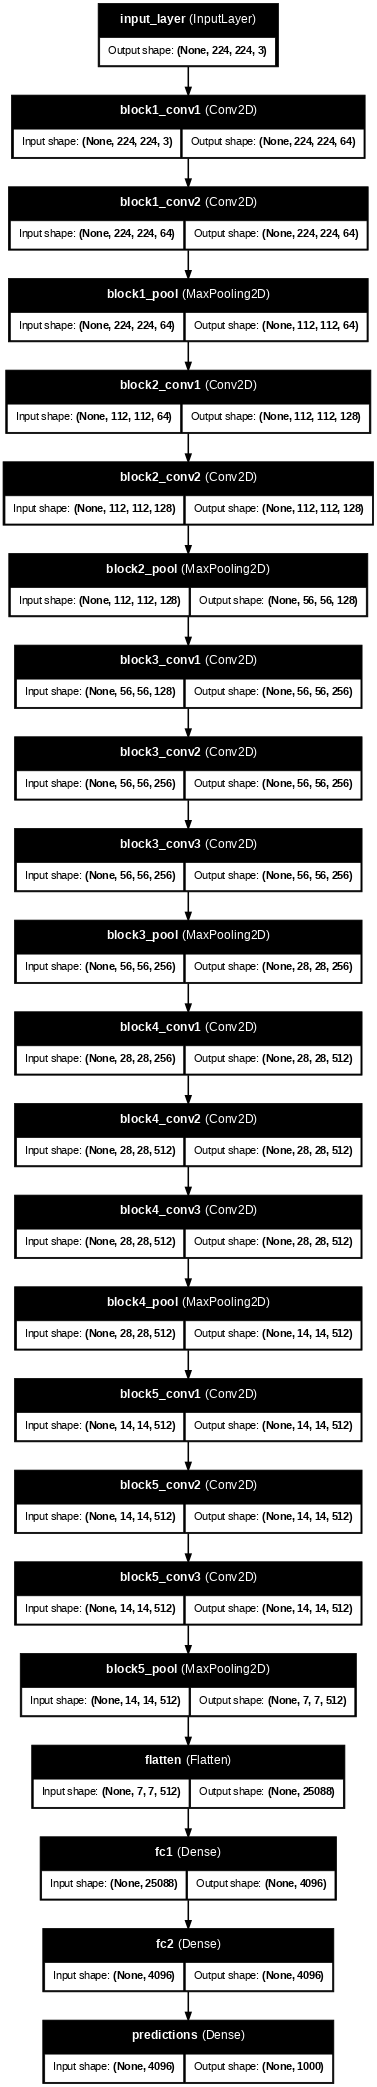

In [ ]:
try:
    keras.utils.plot_model(vgg_full, to_file="vgg16_graph.png",
                           show_shapes=True, show_layer_names=True, dpi=55)
    display(IPImage("vgg16_graph.png"))
except Exception as e:
    print("plot_model unavailable ->", e)
    print("Run:  !pip -q install pydot && apt-get -qq install graphviz")

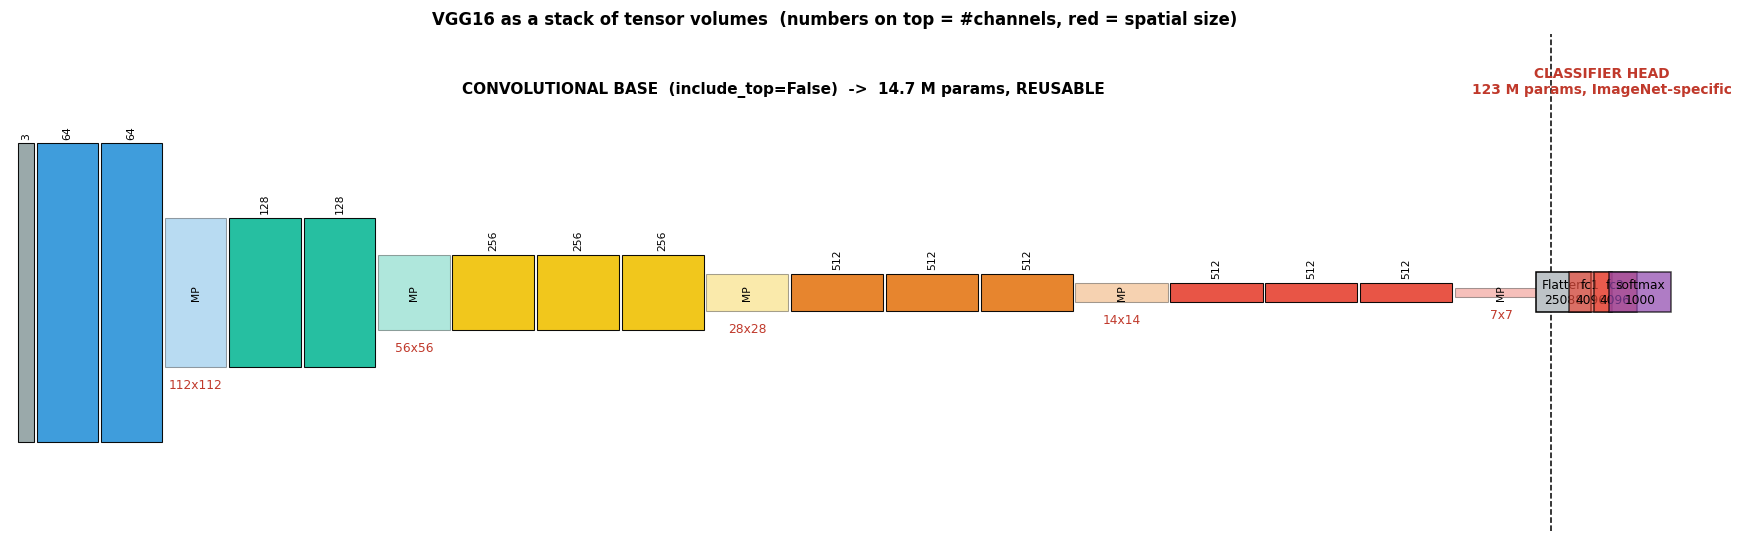

In [ ]:
BLOCK_COLORS = {"block1": "#3498db", "block2": "#1abc9c", "block3": "#f1c40f",
                "block4": "#e67e22", "block5": "#e74c3c"}

fig, ax = plt.subplots(figsize=(16, 5))
x = 0.0
for name, shp in conv:
    sp, ch = shp[1], shp[3]
    h = 3.0 * sp / 224.0
    w = math.log2(ch) / 2.2
    pool = "pool" in name
    color = BLOCK_COLORS.get(name.split("_")[0], "#95a5a6")
    ax.add_patch(plt.Rectangle((x, -h / 2), w, h, facecolor=color,
                               edgecolor="black", lw=.7, alpha=.35 if pool else .95))
    if pool:
        ax.text(x + w / 2, -h / 2 - 0.22, f"{sp}x{sp}", ha="center", fontsize=8, color="#c0392b")
        ax.text(x + w / 2, 0, "MP", ha="center", va="center", fontsize=7, rotation=90)
    else:
        ax.text(x + w / 2, h / 2 + 0.06, str(ch), ha="center", fontsize=7, rotation=90)
    x += w + 0.12

ax.text(x + 0.6, 0, "Flatten\n25088", ha="center", va="center", fontsize=8,
        bbox=dict(fc="#bdc3c7", ec="k"))
ax.text(x + 1.8, 0, "fc1\n4096", ha="center", va="center", fontsize=8,
        bbox=dict(fc="#e74c3c", alpha=.7, ec="k"))
ax.text(x + 2.9, 0, "fc2\n4096", ha="center", va="center", fontsize=8,
        bbox=dict(fc="#e74c3c", alpha=.7, ec="k"))
ax.text(x + 4.0, 0, "softmax\n1000", ha="center", va="center", fontsize=8,
        bbox=dict(fc="#8e44ad", alpha=.7, ec="k"))
ax.axvline(x + 0.05, ls="--", c="k", lw=1)
ax.text(x / 2, 2.0, "CONVOLUTIONAL BASE  (include_top=False)  ->  14.7 M params, REUSABLE",
        ha="center", fontsize=10, fontweight="bold")
ax.text(x + 2.3, 2.0, "CLASSIFIER HEAD\n123 M params, ImageNet-specific",
        ha="center", fontsize=9, fontweight="bold", color="#c0392b")
ax.set_xlim(-.3, x + 4.8); ax.set_ylim(-2.4, 2.6); ax.axis("off")
ax.set_title("VGG16 as a stack of tensor volumes  (numbers on top = #channels, red = spatial size)",
             fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
FLOWERS_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
DOG_URL     = "https://storage.googleapis.com/download.tensorflow.org/example_images/YellowLabradorLooking_new.jpg"

p = keras.utils.get_file(origin=FLOWERS_URL, extract=True)
root = pathlib.Path(p)
if root.is_file():
    root = root.parent
cands = [d for d in root.rglob("flower_photos") if d.is_dir()]
DATA_DIR = cands[0] if cands else root
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

dog_path = keras.utils.get_file("labrador.jpg", DOG_URL)

print("flower_photos at :", DATA_DIR)
print("classes          :", CLASS_NAMES)
for c in CLASS_NAMES:
    print(f"   {c:<12} {len(list((DATA_DIR/c).glob('*.jpg')))} images")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
83281/83281 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
flower_photos at : /root/.keras/datasets/flower_photos.tgz/flower_photos
classes          : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
   daisy        633 images
   dandelion    898 images
   roses        641 images
   sunflowers   699 images
   tulips       799 images


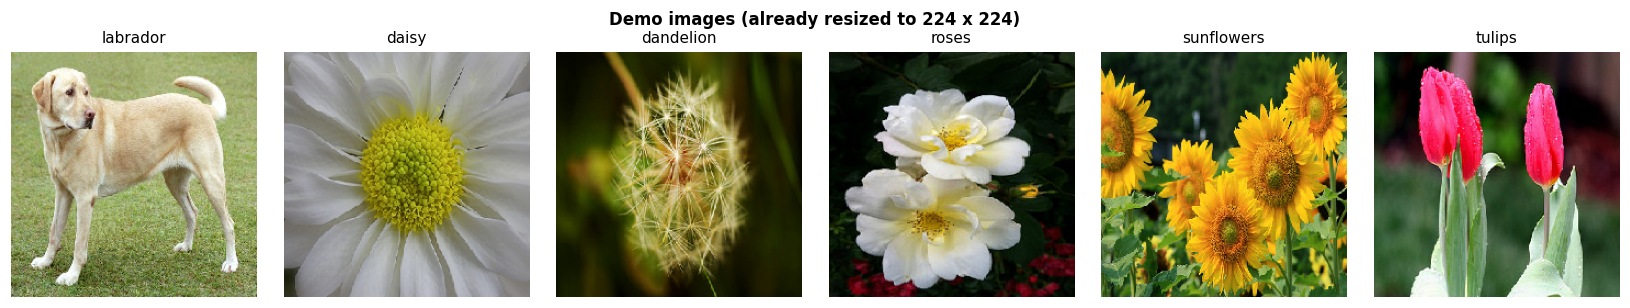

In [ ]:
def load_img_array(path, size=(224, 224)):
    """Load an image, resize to 224x224, return float32 array in [0,255] (RGB)."""
    img = keras.utils.load_img(str(path), target_size=size)
    return keras.utils.img_to_array(img)          # shape (224,224,3), 0..255

def show(ax, arr01, title=None, fs=8):
    ax.imshow(np.clip(arr01, 0, 1)); ax.axis("off")
    if title: ax.set_title(title, fontsize=fs)

# 6 demo images: 1 dog + 1 of each flower class
demo_paths  = [dog_path] + [sorted((DATA_DIR/c).glob("*.jpg"))[0] for c in CLASS_NAMES]
demo_labels = ["labrador"] + CLASS_NAMES
demo_raw    = np.stack([load_img_array(p) for p in demo_paths])      # (6,224,224,3) 0..255
demo_x      = preprocess_input(demo_raw.copy())                      # VGG-ready

fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
for a, im, t in zip(axes, demo_raw, demo_labels):
    show(a, im/255., t, 10)
plt.suptitle("Demo images (already resized to 224 x 224)", fontweight="bold")
plt.tight_layout(); plt.show()

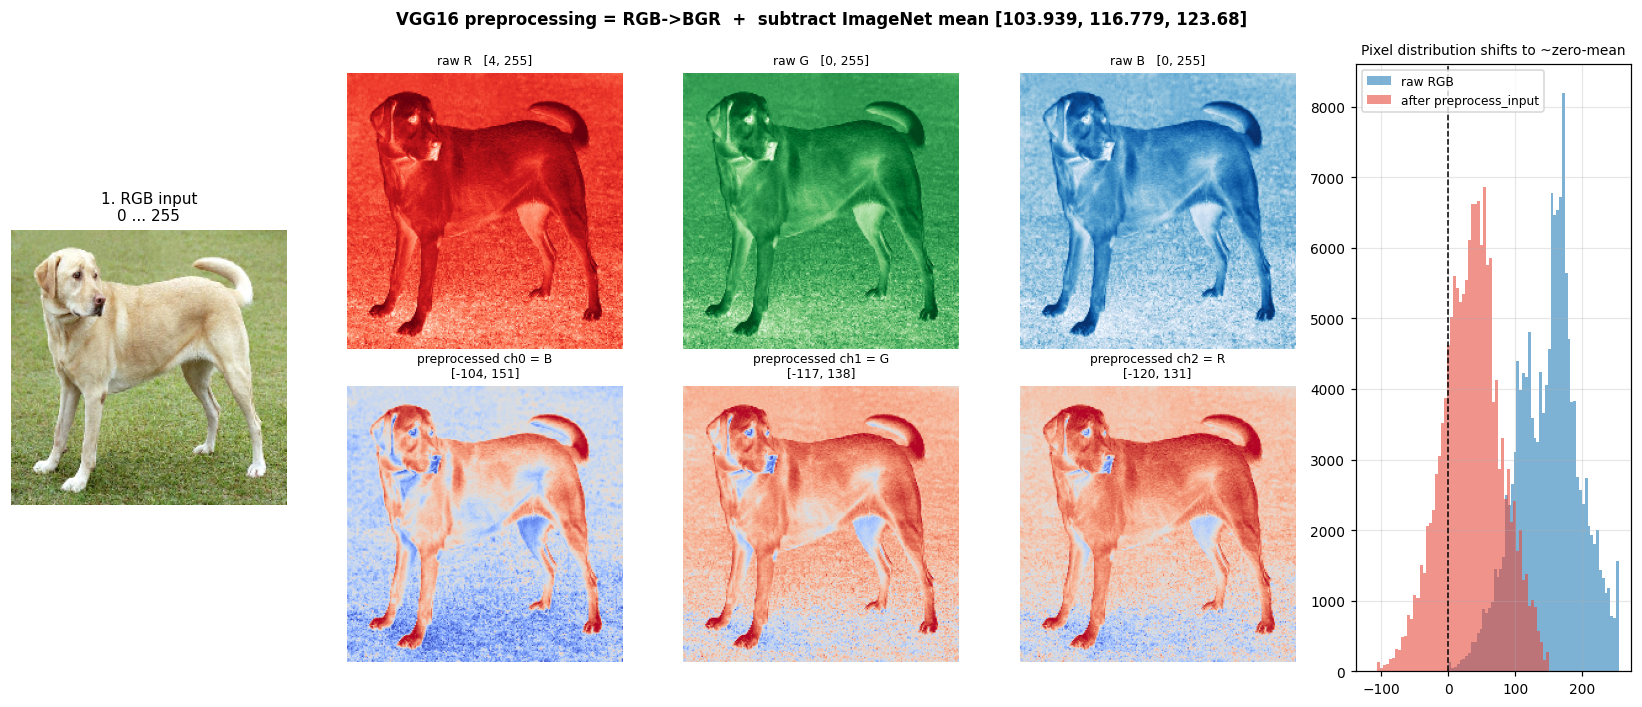

mean per channel BEFORE : [163.61 167.6  118.86]
mean per channel AFTER  : [14.92 50.84 39.96]


In [ ]:
raw = demo_raw[0]
pre = preprocess_input(raw.copy())

fig = plt.figure(figsize=(15, 6.5))
gs  = gridspec.GridSpec(2, 5, figure=fig)

ax = fig.add_subplot(gs[:, 0]); show(ax, raw/255., "1. RGB input\n0 ... 255", 10)

for i, (ch, cm) in enumerate(zip(["R", "G", "B"], ["Reds", "Greens", "Blues"])):
    ax = fig.add_subplot(gs[0, i+1]); ax.imshow(raw[..., i], cmap=cm); ax.axis("off")
    ax.set_title(f"raw {ch}   [{raw[...,i].min():.0f}, {raw[...,i].max():.0f}]", fontsize=8)

for i, ch in enumerate(["B", "G", "R"]):
    ax = fig.add_subplot(gs[1, i+1]); im = ax.imshow(pre[..., i], cmap="coolwarm"); ax.axis("off")
    ax.set_title(f"preprocessed ch{i} = {ch}\n[{pre[...,i].min():.0f}, {pre[...,i].max():.0f}]", fontsize=8)

ax = fig.add_subplot(gs[:, 4])
ax.hist(raw.ravel(), bins=60, alpha=.6, label="raw RGB", color="#2980b9")
ax.hist(pre.ravel(), bins=60, alpha=.6, label="after preprocess_input", color="#e74c3c")
ax.axvline(0, c="k", ls="--", lw=1); ax.legend(fontsize=8); ax.grid(alpha=.3)
ax.set_title("Pixel distribution shifts to ~zero-mean", fontsize=9)

plt.suptitle("VGG16 preprocessing = RGB->BGR  +  subtract ImageNet mean [103.939, 116.779, 123.68]",
             fontweight="bold")
plt.tight_layout(); plt.show()

print("mean per channel BEFORE :", raw.mean(axis=(0,1)).round(2))
print("mean per channel AFTER  :", pre.mean(axis=(0,1)).round(2))

softmax output shape: (6, 1000)  (6 images x 1000 ImageNet classes)
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


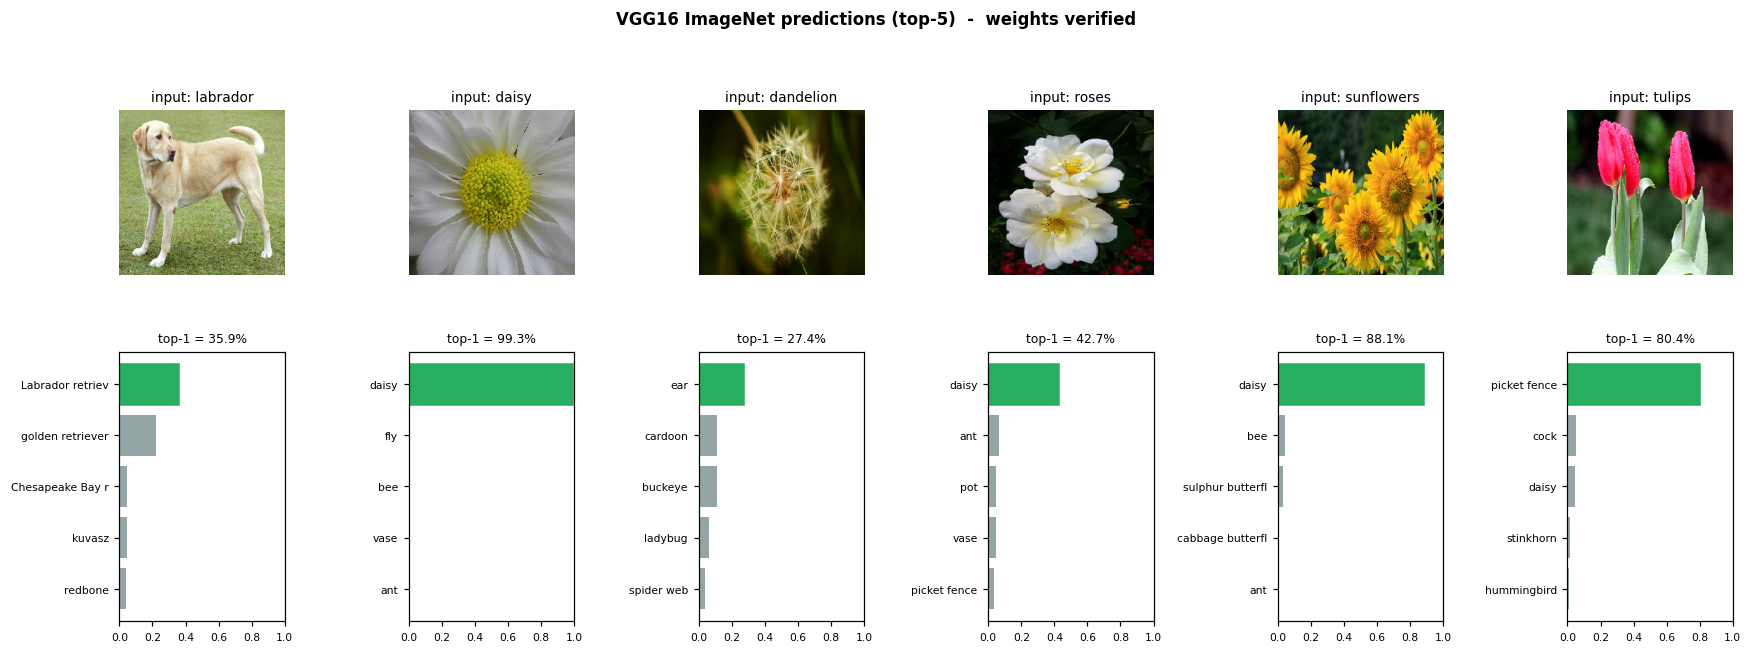

In [ ]:
probs = vgg_full.predict(demo_x, verbose=0)
print("softmax output shape:", probs.shape, " (6 images x 1000 ImageNet classes)")
top5 = decode_predictions(probs, top=5)

fig, axes = plt.subplots(2, 6, figsize=(16, 6),
                         gridspec_kw=dict(height_ratios=[1.1, 1]))
for j in range(6):
    show(axes[0, j], demo_raw[j]/255., f"input: {demo_labels[j]}", 9)
    names = [t[1].replace("_", " ")[:16] for t in top5[j]][::-1]
    vals  = [t[2] for t in top5[j]][::-1]
    bars  = axes[1, j].barh(names, vals, color="#95a5a6")
    bars[-1].set_color("#27ae60")
    axes[1, j].set_xlim(0, 1); axes[1, j].tick_params(labelsize=7)
    axes[1, j].set_title(f"top-1 = {vals[-1]*100:.1f}%", fontsize=8)
plt.suptitle("VGG16 ImageNet predictions (top-5)  -  weights verified", fontweight="bold")
plt.tight_layout(); plt.show()

In [ ]:
vgg_base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
vgg_base.trainable = False                     # FREEZE - this is what "feature extraction" means

print("conv-base output shape :", tuple(vgg_base.output.shape))
print("trainable params       :", f"{sum(np.prod(w.shape) for w in vgg_base.trainable_weights):,}")
print("frozen params          :", f"{vgg_base.count_params():,}")

# three different "feature vector" definitions
flat_model = keras.Model(vgg_base.input, keras.layers.Flatten()(vgg_base.output), name="feat_flatten")
gap_model  = keras.Model(vgg_base.input, keras.layers.GlobalAveragePooling2D()(vgg_base.output), name="feat_gap")
fc1_model  = keras.Model(vgg_full.input, vgg_full.get_layer("fc1").output, name="feat_fc1")

f_map, f_flat, f_gap, f_fc1 = (vgg_base.predict(demo_x, verbose=0),
                               flat_model.predict(demo_x, verbose=0),
                               gap_model.predict(demo_x,  verbose=0),
                               fc1_model.predict(demo_x,  verbose=0))
print("\nfeature map (block5_pool):", f_map.shape)
print("Flatten                  :", f_flat.shape)
print("GlobalAveragePooling2D   :", f_gap.shape)
print("fc1 activations          :", f_fc1.shape)
print(f"\nCompression: 224*224*3 = {224*224*3:,} pixels  ->  {f_gap.shape[1]} numbers "
      f"({224*224*3/f_gap.shape[1]:.0f}x smaller, but far more meaningful)")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step
conv-base output shape : (None, 7, 7, 512)
trainable params       : 0
frozen params          : 14,714,688



feature map (block5_pool): (6, 7, 7, 512)
Flatten                  : (6, 25088)
GlobalAveragePooling2D   : (6, 512)
fc1 activations          : (6, 4096)

Compression: 224*224*3 = 150,528 pixels  ->  512 numbers (294x smaller, but far more meaningful)


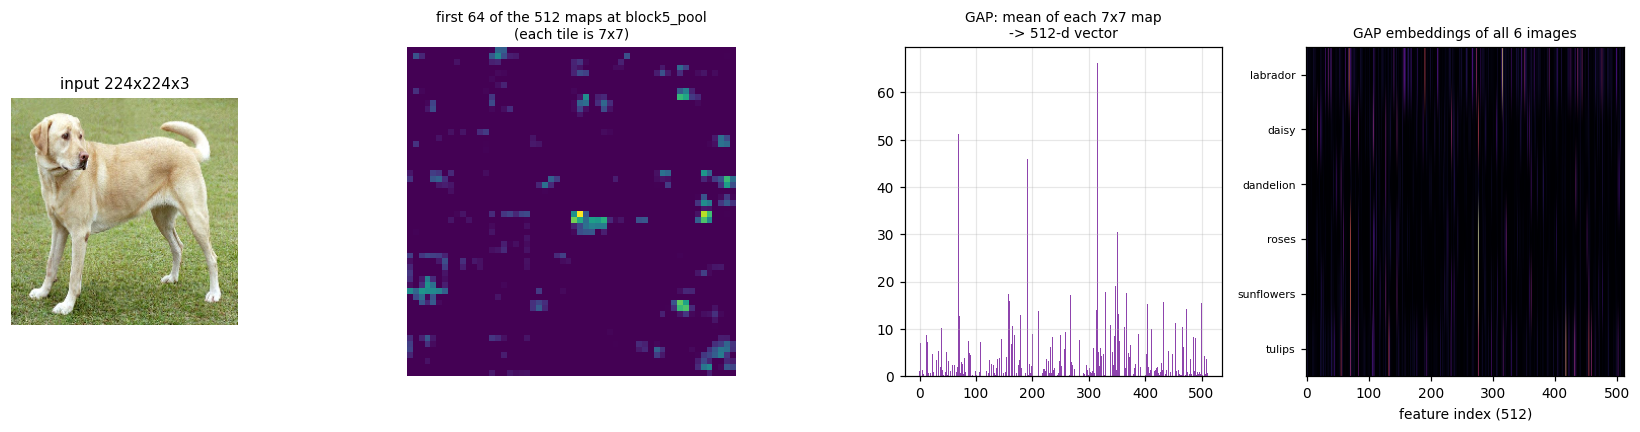

In [ ]:
# ---- the 512 feature maps of ONE image, and how pooling collapses them -----
fm = f_map[0]                                    # (7,7,512)
fig = plt.figure(figsize=(15, 4))
gs  = gridspec.GridSpec(1, 4, width_ratios=[1, 2.2, 1.4, 1.4])

ax = fig.add_subplot(gs[0]); show(ax, demo_raw[0]/255., "input 224x224x3", 10)

ax = fig.add_subplot(gs[1])
grid = np.zeros((7*8, 7*8))
for k in range(64):
    r, c = divmod(k, 8)
    grid[r*7:(r+1)*7, c*7:(c+1)*7] = fm[..., k]
ax.imshow(grid, cmap="viridis"); ax.axis("off")
ax.set_title("first 64 of the 512 maps at block5_pool\n(each tile is 7x7)", fontsize=9)

ax = fig.add_subplot(gs[2])
ax.bar(range(512), fm.mean(axis=(0,1)), width=1.0, color="#8e44ad")
ax.set_title("GAP: mean of each 7x7 map\n-> 512-d vector", fontsize=9); ax.grid(alpha=.3)

ax = fig.add_subplot(gs[3])
ax.imshow(f_gap, aspect="auto", cmap="magma")
ax.set_yticks(range(6)); ax.set_yticklabels(demo_labels, fontsize=7)
ax.set_xlabel("feature index (512)"); ax.set_title("GAP embeddings of all 6 images", fontsize=9)

plt.tight_layout(); plt.show()

block1_conv1 kernel tensor: (3, 3, 3, 64)  -> 3*3*3*64 + 64 = 1792 params


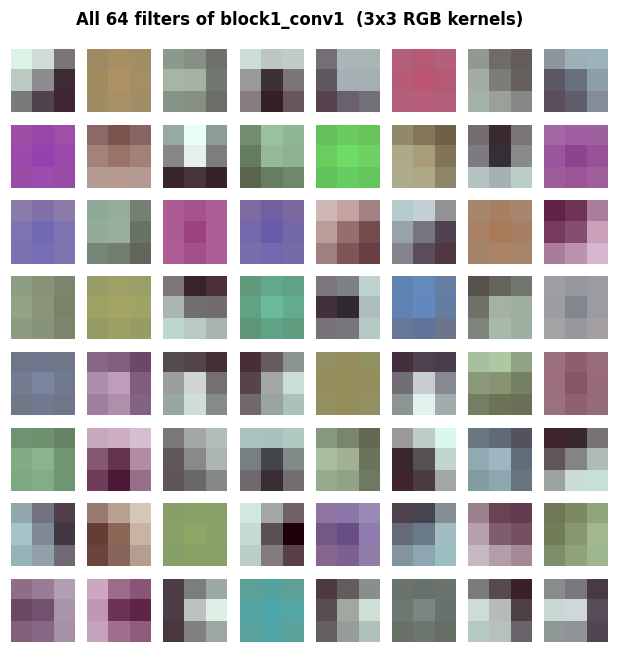

block3_conv1 kernel tensor: (3, 3, 128, 256) -> 128 input channels, cannot be shown as RGB.


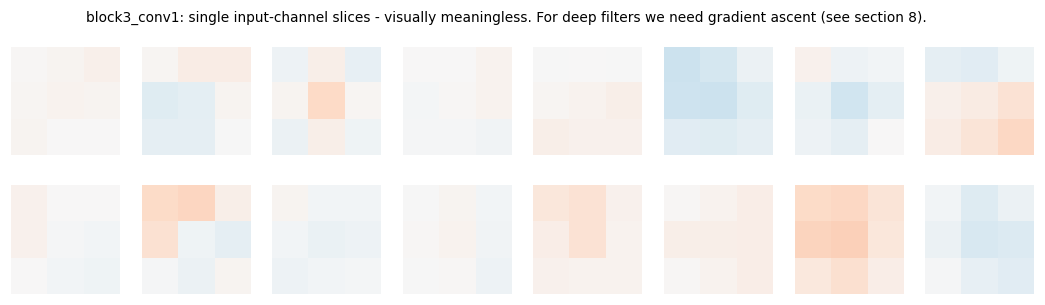

In [ ]:
W = vgg_base.get_layer("block1_conv1").get_weights()[0]     # (3,3,3,64)
print("block1_conv1 kernel tensor:", W.shape, " -> 3*3*3*64 + 64 =", W.size + 64, "params")

Wn = (W - W.min()) / (W.max() - W.min())                    # scale to [0,1] for display
fig, axes = plt.subplots(8, 8, figsize=(7, 7))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(Wn[..., i], interpolation="nearest"); ax.axis("off")
plt.suptitle("All 64 filters of block1_conv1  (3x3 RGB kernels)", fontweight="bold", y=.93)
plt.show()

# deeper filters have >3 input channels -> not directly viewable as colour images
W3 = vgg_base.get_layer("block3_conv1").get_weights()[0]
print("block3_conv1 kernel tensor:", W3.shape, "-> 128 input channels, cannot be shown as RGB.")
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(W3[..., i % 128, i], cmap="RdBu_r", vmin=-.2, vmax=.2); ax.axis("off")
plt.suptitle("block3_conv1: single input-channel slices - visually meaningless. "
             "For deep filters we need gradient ascent (see section 8).", fontsize=9)
plt.show()

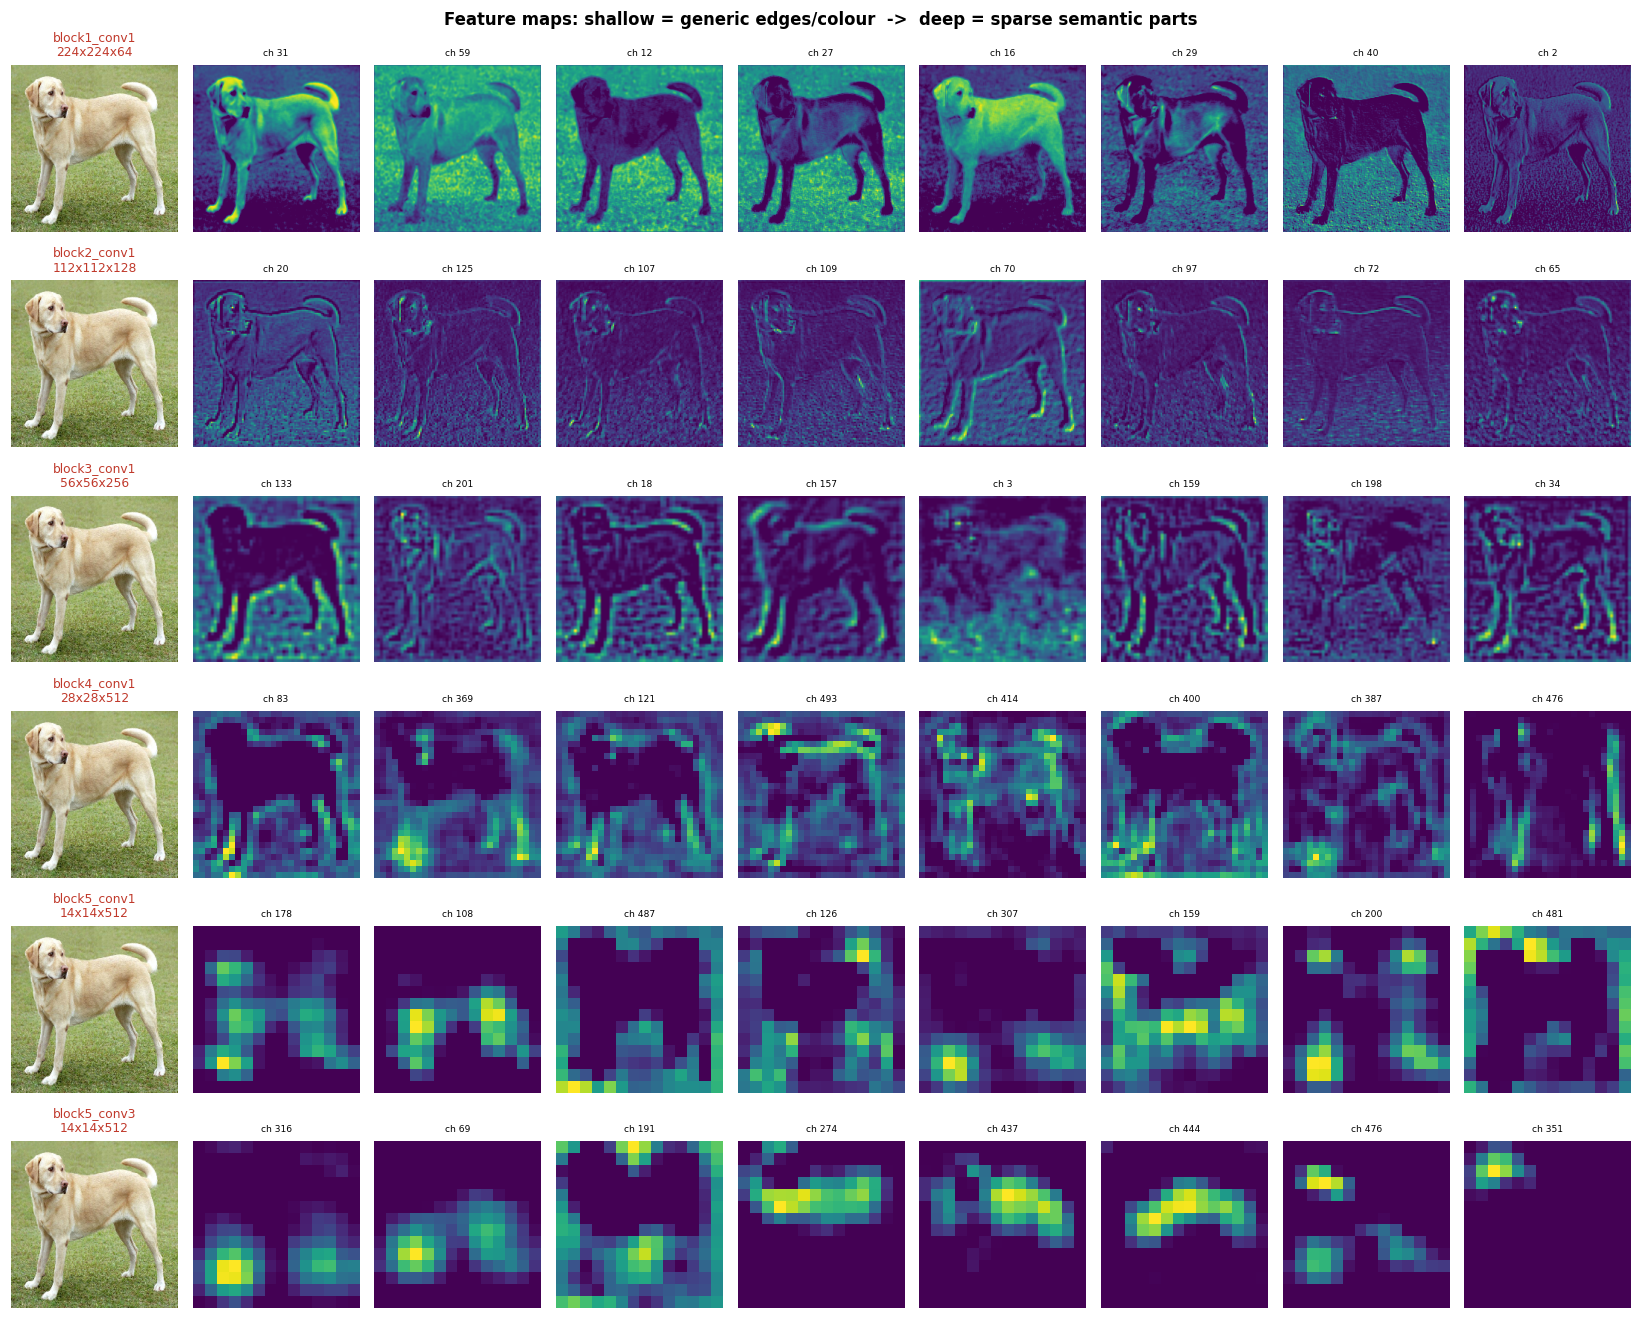

In [ ]:
LAYERS = ["block1_conv1", "block2_conv1", "block3_conv1",
          "block4_conv1", "block5_conv1", "block5_conv3"]
act_model = keras.Model(vgg_base.input,
                        [vgg_base.get_layer(n).output for n in LAYERS])

IMG_ID = 0                                   # <-- change to 1..5 to inspect a flower
acts = act_model.predict(demo_x[IMG_ID:IMG_ID+1], verbose=0)

NCH = 8
fig, axes = plt.subplots(len(LAYERS), NCH + 1, figsize=(15, 2.05*len(LAYERS)))
for r, (name, a) in enumerate(zip(LAYERS, acts)):
    a = a[0]
    show(axes[r, 0], demo_raw[IMG_ID]/255.)
    axes[r, 0].set_title(f"{name}\n{a.shape[0]}x{a.shape[1]}x{a.shape[2]}", fontsize=8, color="#c0392b")
    # pick the 8 most-activated channels so the panels are not blank
    order = np.argsort(a.mean(axis=(0,1)))[::-1][:NCH]
    for c, k in enumerate(order):
        axes[r, c+1].imshow(a[..., k], cmap="viridis"); axes[r, c+1].axis("off")
        axes[r, c+1].set_title(f"ch {k}", fontsize=6)
plt.suptitle("Feature maps: shallow = generic edges/colour  ->  deep = sparse semantic parts",
             fontweight="bold")
plt.tight_layout(); plt.show()

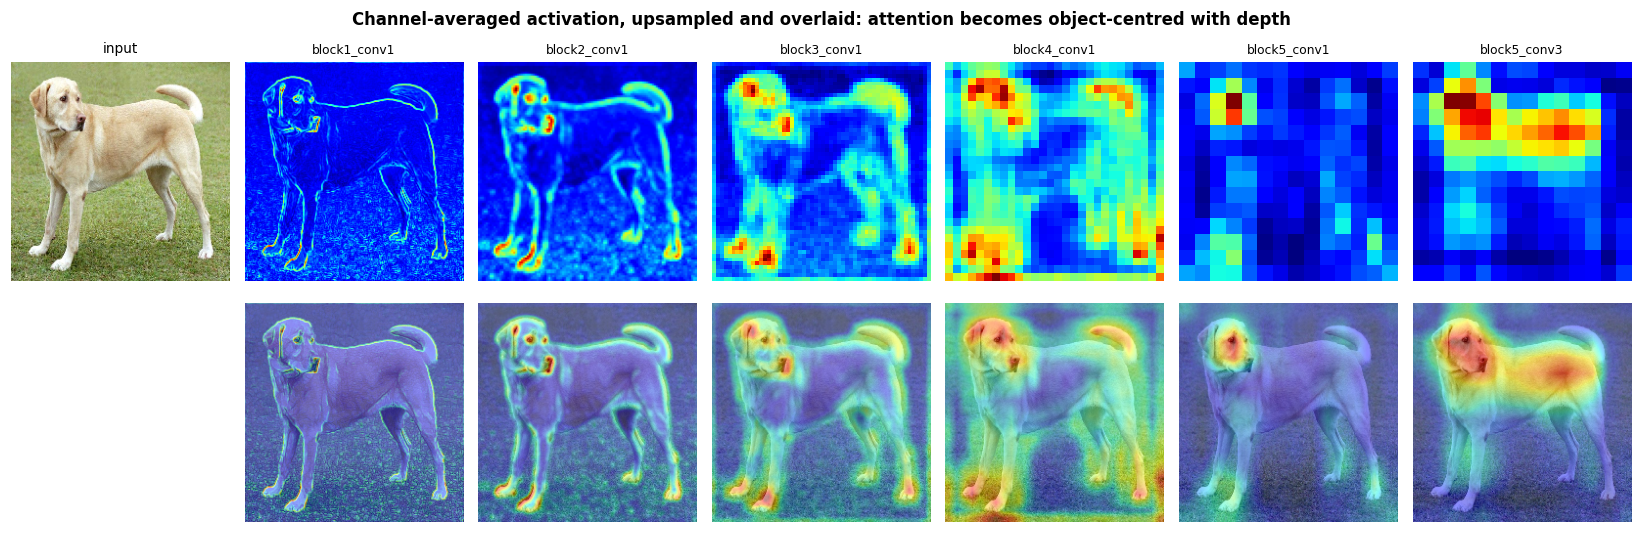

In [ ]:
# ---- "where is the network looking?"  mean activation heat-map overlay -----
fig, axes = plt.subplots(2, len(LAYERS)+1, figsize=(15, 5))
for col in range(len(LAYERS)+1):
    if col == 0:
        show(axes[0, col], demo_raw[IMG_ID]/255., "input", 9); axes[1, col].axis("off")
        continue
    a = acts[col-1][0]
    heat = a.mean(axis=-1)
    heat = (heat - heat.min()) / (heat.max() - heat.min() + 1e-8)
    axes[0, col].imshow(heat, cmap="jet"); axes[0, col].axis("off")
    axes[0, col].set_title(LAYERS[col-1], fontsize=8)
    big = tf.image.resize(heat[..., None], (224, 224)).numpy()[..., 0]
    axes[1, col].imshow(demo_raw[IMG_ID]/255.)
    axes[1, col].imshow(big, cmap="jet", alpha=.45); axes[1, col].axis("off")
plt.suptitle("Channel-averaged activation, upsampled and overlaid: attention becomes object-centred with depth",
             fontweight="bold")
plt.tight_layout(); plt.show()

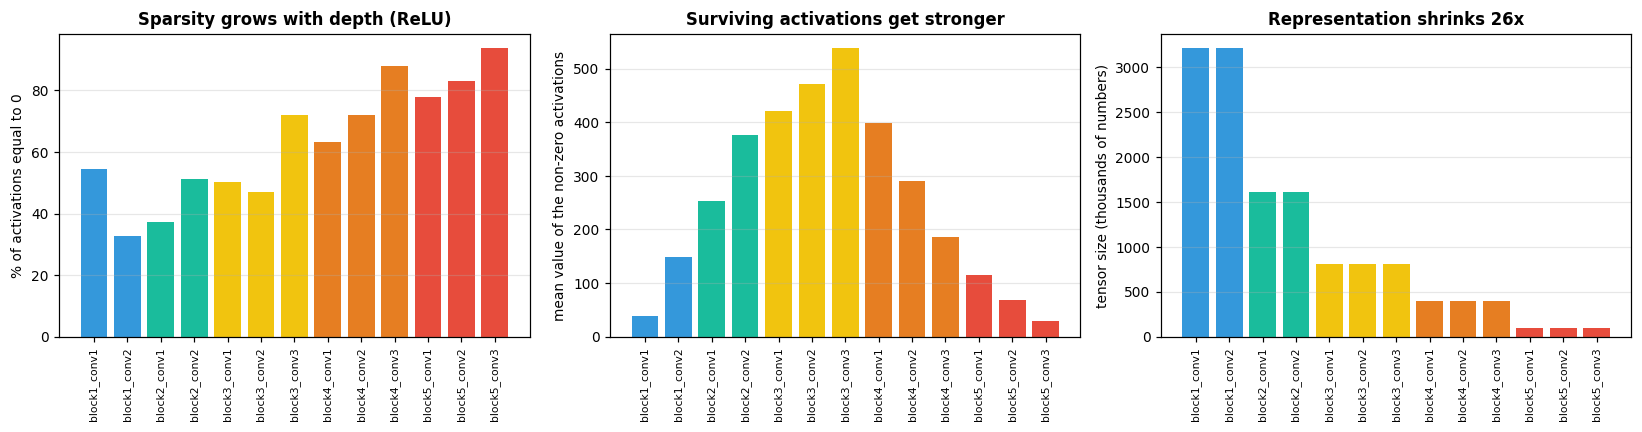

block1_conv1: 3,211,264 numbers, 54% zero
block5_conv3: 100,352 numbers, 94% zero


In [ ]:
CONV = [l.name for l in vgg_base.layers if "conv" in l.name]
all_model = keras.Model(vgg_base.input, [vgg_base.get_layer(n).output for n in CONV])
A = all_model.predict(demo_x[IMG_ID:IMG_ID+1], verbose=0)

zeros = [float((a == 0).mean()) * 100 for a in A]
means = [float(a[a > 0].mean()) for a in A]
sizes = [int(np.prod(a.shape[1:])) for a in A]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cs = [BLOCK_COLORS[n.split("_")[0]] for n in CONV]
ax[0].bar(CONV, zeros, color=cs); ax[0].set_ylabel("% of activations equal to 0")
ax[0].set_title("Sparsity grows with depth (ReLU)", fontweight="bold")
ax[1].bar(CONV, means, color=cs); ax[1].set_ylabel("mean value of the non-zero activations")
ax[1].set_title("Surviving activations get stronger", fontweight="bold")
ax[2].bar(CONV, np.array(sizes)/1000, color=cs); ax[2].set_ylabel("tensor size (thousands of numbers)")
ax[2].set_title("Representation shrinks 26x", fontweight="bold")
for a in ax:
    a.tick_params(axis="x", rotation=90, labelsize=7); a.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

print(f"block1_conv1: {sizes[0]:,} numbers, {zeros[0]:.0f}% zero")
print(f"block5_conv3: {sizes[-1]:,} numbers, {zeros[-1]:.0f}% zero")